In [1]:
import cornac
from cornac.data import Reader
from cornac.datasets import movielens
from cornac.data import Dataset, FeatureModality
from cornac.eval_methods import RatioSplit, StratifiedSplit
from cornac.metrics import RMSE, AUC, NDCG, Precision, Recall
from cornac.models import (
    MF,
    ItemKNN,
    UserKNN,
    NMF,
    BPR,
    LightGCN,
    SVD,
    MostPop,
    NeuMF,
    VAECF,NGCF
)
import pandas as pd
import numpy as np
import random
import math
from collections import OrderedDict
import seaborn as sns
import matplotlib.pyplot as plt

/Users/tahsinalamgirkheya/anaconda3/envs/cornac/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
reader = Reader()
rating_data_pd = pd.read_csv(
    "./cornac/data_c/indexed_interactions.csv",
    sep="\t",
    header=None,
    names=["userID", "itemID", "Rating", "Timestamp"],
)
# print(rating_data["itemID"].nunique())
# rating_data = rating_data.drop(columns=rating_data.columns[-1])
rating_data = rating_data_pd.to_numpy()
rating_data.__len__()

999611

In [3]:
# movie_data = reader.read(fpath="./data/indexed_movies.csv", sep=",", fmt="UIRT")
# movie_data
movies = pd.read_csv("./cornac/data_c/indexed_movies.csv")

movies = movies.drop(columns=movies.columns[0])
movies[:4]

# unique_genres = set("|".join(movies["genres"]).split("|"))
# unique_genres = list(unique_genres)
unique_genres = [
    "Action",
    "Thriller",
    "Romance",
    "Western",
    "Children's",
    "Mystery",
    "Fantasy",
    "Film-Noir",
    "Documentary",
    "Comedy",
    "Adventure",
    "Sci-Fi",
    "Horror",
    "Crime",
    "Musical",
    "War",
    "Animation",
    "Drama",
]
for genre in unique_genres:
    movies[genre] = 0
for index, row in movies.iterrows():
    genres = row["genres"].split("|")
    for genre in genres:
        movies.at[index, genre] = 1

# item_categories = movies[unique_genres]
# unique_iids = rating_data_pd['itemID'].unique()
# movies = movies[movies['itemID'].isin(unique_iids)]
genre = movies[unique_genres]
item_features_numpy = genre.to_numpy()
# print(item_features_numpy.shape)

# item_categories = item_categor
item_features = {
    str(item_id): {"genre_" + str(idx): value for idx, value in enumerate(row)}
    for item_id, row in enumerate(item_features_numpy)
}
ids = list(range(0, 3416))
# item_feature_modality = FeatureModality(
#     features=item_features_numpy, ids=ids, normalized=True
# )


users = pd.read_csv("./cornac/data_c/u_id_mapping.csv", sep="\t")
users = users.drop(columns=users.columns[0])
gender_map = {"M": 0, "F": 1}
users["Gender"] = users["Gender"].map(gender_map)
# unique_uids = rating_data_pd['userID'].unique()

# users = users[users["userID"].isin(unique_uids)]
user_features_numpy = users.to_numpy()
print(user_features_numpy.shape)
print(item_features_numpy.shape)
# user_feature_modality = FeatureModality(
#     features=user_features_numpy, name="user", normalized=True, ids=list(range(0, 6040))
# )

# print("Example Item Features:")
# for item_id, features in list(item_features.items())[:5]:
#     print(f"Item ID: {item_id}, Features: {features}")

(6040, 2)
(3416, 18)


In [4]:
dataset = rating_data
unique_genres.__len__()

18

In [5]:
ratio_split = StratifiedSplit(
    data=dataset,
    test_size=0.1,
    rating_threshold=0.0,
    seed=123,
    verbose=True,
    chrono=True,
    user_features=user_features_numpy[:, 0],
    item_features=item_features_numpy,val_size=0.1,
    exclude_unknowns=False,
)
rec_50 = cornac.metrics.Recall(k=50)
ndcg_50 = cornac.metrics.NDCG(k=50)
auc = cornac.metrics.AUC()
rmse = cornac.metrics.RMSE()
prec = cornac.metrics.Precision(k=50)
hr = cornac.metrics.HitRatio(k=50)
mrr = cornac.metrics.MRR()
map = cornac.metrics.MAP()


models = []


model_1 = UserKNN(k=20, seed=123, verbose=True)
model_2 = ItemKNN(k=20, seed=123, verbose=True)
model_3 = MF(
    k=20,
    seed=123,
    name=f"a={0} mf",
    backend="pytorch",
    verbose=True,
    optimizer="adam",
    alpha=0,
    learning_rate=0.001,
)
model_4 = VAECF(
    k=20,
    autoencoder_structure=[100],
    act_fn="tanh",
    likelihood="mult",
    n_epochs=100,
    batch_size=100,
    learning_rate=0.001,
    beta=1.0,
    seed=123,
    verbose=True,
)
model_5 = LightGCN(
    seed=123,
    verbose=True,
    emb_size=64,num_epochs=600,
    early_stopping={"min_delta": 0.001, "patience": 20},
)
model_6 = NGCF(seed=123,verbose=True,
    emb_size=64,num_epochs=600,
    early_stopping={"min_delta": 0.001, "patience": 20},)
models = [model_3]


cornac.Experiment(
    ratio_split, models=models, metrics=[rec_50, ndcg_50, auc, rmse, prec, hr, mrr, map]
).run()

rating_threshold = 0.0
exclude_unknowns = False
::::::::
OrderedDict()
OrderedDict()
::::::::
---
Training data:
(array([   0,    0,    0, ..., 6039, 6039, 6039]), array([  0,   1,   2, ..., 422, 749, 822]), array([4., 5., 4., ..., 4., 4., 3.]))
Number of users = 6040
Number of items = 3415
Number of ratings = 794217
Max rating = 5.0
Min rating = 1.0
Global mean = 3.6
::::::::
OrderedDict([(6039, 0), (6038, 1), (6037, 2), (6036, 3), (6035, 4), (6034, 5), (6033, 6), (6032, 7), (6031, 8), (6030, 9), (6029, 10), (6028, 11), (6027, 12), (6026, 13), (6025, 14), (6024, 15), (6023, 16), (6022, 17), (6021, 18), (6020, 19), (6019, 20), (6018, 21), (6017, 22), (6016, 23), (6015, 24), (6014, 25), (6013, 26), (6012, 27), (6011, 28), (6010, 29), (6009, 30), (6008, 31), (6006, 32), (6007, 33), (6005, 34), (6004, 35), (6003, 36), (6002, 37), (6001, 38), (6000, 39), (5999, 40), (5998, 41), (5997, 42), (5996, 43), (5995, 44), (5994, 45), (5993, 46), (5992, 47), (5991, 48), (5990, 49), (5989, 50), (5988

  0%|          | 0/20 [00:01<?, ?it/s, loss=1.13]


KeyboardInterrupt: 

In [ ]:
user_ids = users.to_numpy()[:, 1]
item_ids = movies.to_numpy()[:, 2]
user_ids.__len__()
# get the top_k ratings for all users:
top_k = 50
reco_matrix = np.zeros((len(models), len(user_ids), top_k), dtype=int)
reco_matrix_mapped_items = np.zeros(
    (len(models), len(user_ids), len(item_ids)), dtype=int
)
reco_matrix_mapped_scores = np.zeros(
    (len(models), len(user_ids), len(item_ids)), dtype=float
)
reco_matrix_all = np.zeros((len(models), len(user_ids), len(item_ids)), dtype=int)


for u in user_ids:
    for i in range(len(models)):
        reco_items = models[i].recommend(u)
        items_mapped, mapped_scores = models[i].rank(
            user_idx=u, item_indices=list(item_ids)
        )
        reco_matrix_mapped_items[i][u] = items_mapped
        reco_matrix_mapped_scores[i][u] = mapped_scores
        reco_matrix_all[i][u] = reco_items
        reco_matrix[i][u] = reco_items[:top_k]

        # print(reco_matrix[0][3])

In [ ]:
####Import Metrics####
from cornac.mymetrics.GenrePrecision import GenrePrecision
from cornac.mymetrics.GenreMap import GenreMap
from cornac.mymetrics.GenreMRR import GenreMRR
from cornac.mymetrics.GenreNDCG import GenreNDCG
from cornac.mymetrics.GenreRecall import GenreRecall
from cornac.mymetrics.GenreRPrecision import GenreRPrecision

top_k = 50
###intialize them
gp = GenrePrecision(users, unique_genres, top_k)
gr = GenreRecall(users, unique_genres, top_k)
gm = GenreMap(users, unique_genres, top_k)
gndcg = GenreNDCG(users, unique_genres, top_k)
gmrr = GenreMRR(users, unique_genres, top_k)

In [ ]:
# for r-precision we wanna take the max of the proportiion of total genre in the movie dataset using ranks
movies_df = movies[unique_genres].div(movies[unique_genres].sum(axis=1), axis=0)
movies_df = movies_df[unique_genres].sum()
new_top_k = math.floor(movies_df.max())


# get the top_k ratings for all users:
reco_matrix_top_r = np.zeros((len(models), len(user_ids), new_top_k), dtype=int)

for u in range(len(user_ids)):
    for i in range(len(models)):
        # reco_items, all_scores = models[i].rank(user_idx=user_ids[i], item_indices=list(item_ids))
        reco_matrix_top_r[i][u] = reco_matrix_all[i][u][:new_top_k]


grp = GenreRPrecision(users, unique_genres, top_k)
# MF_grp = grp.compute(reco_matrix_top_r, movies_df, movies)

In [ ]:
####IR Metrics####
model_gps = []
model_grs = []
model_gms = []
model_gdcgs = []
model_gmrrs = []

for i in range(len(models)):
    ####Precision####
    model_gps.append(gp.compute(reco_matrix[i], movies))
    ####Recall####
    model_grs.append(gr.compute(reco_matrix[i], movies))
    ####MAP Mean Average Precision####
    model_gms.append(gm.compute(reco_matrix[i], movies))
    ####DCG####
    model_gdcgs.append(gndcg.compute(reco_matrix[i], movies))
    ####MRR####
    model_gmrrs.append(gmrr.compute(reco_matrix[i], movies))

In [ ]:
model_grps = []
for i in range(len(models)):
    model_grps.append(grp.compute(reco_matrix_top_r[i], movies_df, movies))

          Action  Thriller   Romance   Western  Children's   Mystery  \
Gender                                                                 
0       0.115005  0.088487  0.054500  0.006577    0.020770  0.013207   
1       0.071093  0.071763  0.098314  0.002957    0.030226  0.013346   

         Fantasy  Film-Noir  Documentary    Comedy  Adventure    Sci-Fi  \
Gender                                                                    
0       0.012056   0.011745     0.002515  0.220500   0.053501  0.079268   
1       0.010138   0.011343     0.002738  0.238119   0.038722  0.044157   

          Horror     Crime   Musical       War  Animation     Drama  
Gender                                                               
0       0.039648  0.033765  0.011797  0.033963   0.016298  0.220524  
1       0.028288  0.025930  0.025059  0.028031   0.023883  0.255932  
[[0.11500526 0.08848718 0.05449971 0.00657682 0.02076954 0.01320725
  0.01205581 0.01174508 0.00251514 0.22049955 0.05350085 0.079

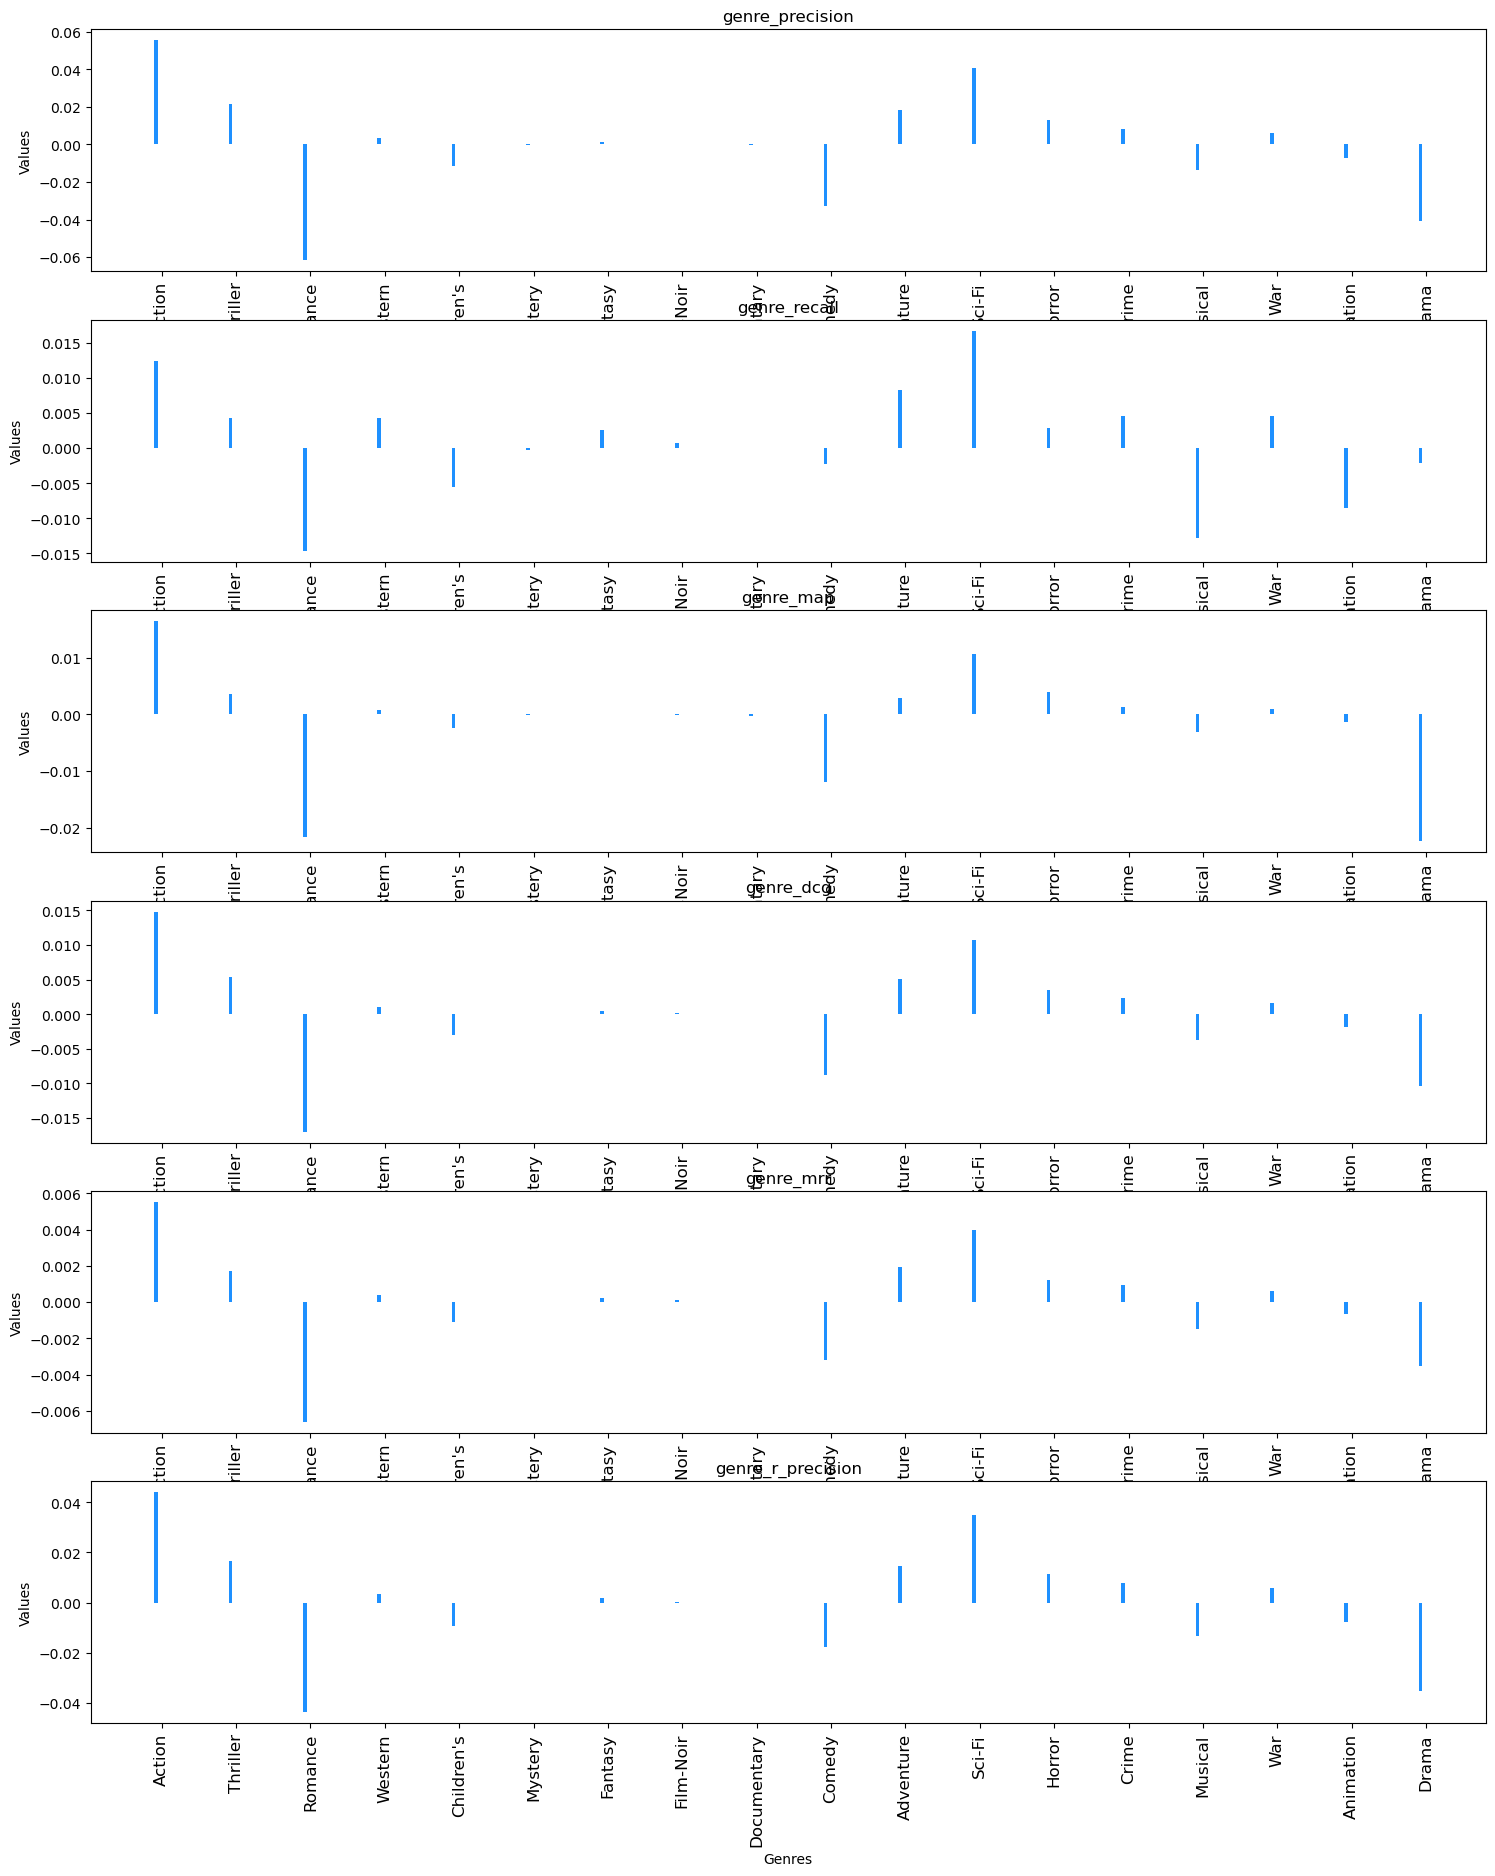

In [ ]:
matrices_1 = [
    model_gps[0],
    model_grs[0],
    model_gms[0],
    model_gdcgs[0],
    model_gmrrs[0],
    model_grps[0],
]
labels = unique_genres
# bar_width = 0.20
titles = [
    "genre_precision",
    "genre_recall",
    "genre_map",
    "genre_dcg",
    "genre_mrr",
    "genre_r_precision",
]


fig, axs = plt.subplots(6, 1, figsize=(18, 22))
axs = axs.flatten()
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.05  # the width of the bars
# rects1 = ax.bar(x - 3*bar_width/2, gender_genre_weights_topk_recom.iloc[0]*100, bar_width, label='Female (Top 50)', color="#bca0dc")


for i in range(len(titles)):
    axs[i].bar(
        x - 3 * bar_width / 2, matrices_1[i], bar_width, color="dodgerblue", label="0"
    )
    # axs[i].bar(x - 1 * bar_width / 2, matrices_2[i], bar_width, color="coral", label="0.1")
    # axs[i].bar(x +1 * bar_width / 2, matrices_3[i], bar_width, color="blue", label="0.2")
    # axs[i].bar(x + 3 * bar_width / 2, matrices_4[i], bar_width, color="pink", label="0.3")
    # axs[i].bar(x + 5 * bar_width / 2, matrices_5[i], bar_width, color="skyblue", label="0.4")
    # axs[i].bar(x + 7 * bar_width / 2, matrices_6[i], bar_width, color="lightgreen", label="0.5")
    # axs[i].bar(x + 9 * bar_width / 2, matrices_7[i], bar_width, color="purple", label="0.6")
    # axs[i].bar(x + 11 * bar_width / 2, matrices_8[i], bar_width, color="violet", label="0.7")
    # axs[i].bar(x + 13 * bar_width / 2, matrices_9[i], bar_width, color="black", label="0.8")
    # axs[i].bar(x + 15 * bar_width / 2, matrices_10[i], bar_width, color="chocolate", label="0.9")
    # axs[i].bar(x + 17 * bar_width / 2, matrices_11[i], bar_width, color="green", label="1")
    # axs[i].bar(x+2*bar_width/2, matrices_3[i], bar_width,color="green")
    # axs[i].bar(labels, matrices_2[i], color="skyblue")
    axs[i].set_xticks(x)
    axs[i].set_xticklabels(unique_genres, rotation=90, fontsize=12)

    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Genres")
    axs[i].set_ylabel("Values")
    axs[i].tick_params(axis="x", rotation=90)

# plt.legend(loc='upper left', fontsize='small', title='Groups')

handles, labels = axs[0].get_legend_handles_labels()